# Black-Litterman with DPP Views — A CVXPY Tutorial

*A hands-on walkthrough of the Black-Litterman model, with CVXPY used
three ways: as a sanity check on the closed-form posterior, as a
natural host for constraint extensions the closed form can't handle,
and as a DPP-cached view-update loop for walk-forward use.*

This notebook completes the CVXPY-finance cookbook's three-tutorial
arc. The first two live here:

- [Mean-variance with transaction costs](./portfolio_optimization_dpp.ipynb)
- [Spinu (2013) risk parity](./risk_parity_spinu.ipynb)

**Three things you will learn:**

1. Black-Litterman is a convex quadratic. The closed-form
   matrix-inversion recipe and a CVXPY `sum_squares` formulation agree
   to solver precision. The latter is slower, but is the right starting
   point for anything beyond the vanilla BL problem.

2. **The CVXPY value-add is constraints, not speed.** Views you can
   express as Gaussian noise go through the closed form fine. Views you
   can only express as inequalities (bounds, rankings, convex hulls) are
   the reason to reach for CVXPY.

3. **DPP-caching brings BL to a production loop.** P, Q as `cp.Parameter`
   gets us a single-compile, re-solvable problem — the inner loop of
   a daily view update.

Plus a walk-forward backtest showing that the BL prior gives MV portfolios
dramatically lower turnover than the raw-historical-mean approach
(~7x lower daily turnover in our universe).


## 0. Setup

In [1]:
from __future__ import annotations

import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

print(f"cvxpy {cp.__version__}  |  numpy {np.__version__}  |  pandas {pd.__version__}")


cvxpy 1.8.2  |  numpy 2.4.3  |  pandas 2.3.3


## 1. Data pipeline

Same 20-ticker universe as the other two tutorials. Historical prices
from `yfinance`, falling back to GBM if offline. Market cap weights are
needed here (they weren't in the other tutorials) because the
Black-Litterman prior `Pi = lambda * Sigma @ w_mkt` depends on them.


In [2]:
TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "TSLA", "BRK-B", "JPM", "JNJ",
    "V", "PG", "UNH", "HD", "MA",
    "DIS", "BAC", "XOM", "PFE", "KO",
]

_STATIC_MARKET_CAPS_T_USD = {
    "AAPL": 3.8, "MSFT": 3.5, "GOOGL": 2.3, "AMZN": 2.2, "META": 1.6,
    "NVDA": 3.2, "TSLA": 1.1, "BRK-B": 1.0, "JPM": 0.7, "JNJ": 0.4,
    "V": 0.6, "PG": 0.4, "UNH": 0.45, "HD": 0.4, "MA": 0.5,
    "DIS": 0.2, "BAC": 0.3, "XOM": 0.5, "PFE": 0.2, "KO": 0.3,
}


def load_prices(tickers, period="2y"):
    try:
        import yfinance as yf
        data = yf.download(tickers, period=period, progress=False, auto_adjust=True)
        if isinstance(data.columns, pd.MultiIndex):
            prices = data["Close"]
        else:
            prices = data[["Close"]]
            prices.columns = tickers[:1]
        prices = prices.dropna(axis=1, how="any")
        if not prices.empty and len(prices) > 260:
            return prices
    except Exception as exc:
        print(f"[warn] yfinance fetch failed ({exc}); using synthetic data")
    rng = np.random.default_rng(42)
    n_days = 504
    drift = rng.uniform(0.05, 0.15, size=len(tickers)) / 252
    vol = rng.uniform(0.15, 0.40, size=len(tickers)) / np.sqrt(252)
    shocks = rng.standard_normal((n_days, len(tickers))) * vol + drift
    prices_arr = 100.0 * np.exp(np.cumsum(shocks, axis=0))
    idx = pd.date_range(end=pd.Timestamp.today(), periods=n_days, freq="B")
    return pd.DataFrame(prices_arr, index=idx, columns=tickers)


def market_cap_weights(tickers):
    caps = []
    try:
        import yfinance as yf
        for t in tickers:
            try:
                cap = float(yf.Ticker(t).info.get("marketCap") or 0.0)
            except Exception:
                cap = 0.0
            if cap <= 0:
                cap = _STATIC_MARKET_CAPS_T_USD.get(t, 0.1) * 1e12
            caps.append(cap)
    except Exception:
        caps = [_STATIC_MARKET_CAPS_T_USD.get(t, 0.1) * 1e12 for t in tickers]
    w = np.array(caps, dtype=float)
    return w / w.sum()


prices = load_prices(TICKERS, period="2y")
w_mkt = market_cap_weights(list(prices.columns))

print(f"Loaded {prices.shape[0]} trading days for {prices.shape[1]} tickers")
print(f"\nMarket-cap weights (normalized):")
for t, w in sorted(zip(prices.columns, w_mkt), key=lambda x: -x[1])[:5]:
    print(f"  {t:<6}  {w*100:5.2f}%")
print(f"  ...")


Loaded 500 trading days for 20 tickers

Market-cap weights (normalized):
  NVDA    17.16%
  GOOGL   14.50%
  AAPL    14.21%
  MSFT    10.66%
  AMZN     9.62%
  ...


## 2. The Black-Litterman model

Start from the CAPM-equilibrium belief that the market-cap-weighted
portfolio is mean-variance optimal. **Reverse optimization** inverts the
usual argmax to recover the *implied equilibrium returns*:

$$\Pi \;=\; \lambda \cdot \Sigma \, w_{\text{mkt}}$$

where $\lambda$ is the market's risk aversion (historically ~2-3 for a
US equity universe). $\Pi$ is the **prior** on expected returns.

Investor **views** are expressed as linear statements on the unknown $\mu$:

$$P\mu = Q + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, \Omega)$$

with $P$ a $k \times n$ "picking" matrix, $Q$ a $k$-vector of target
view returns, and $\Omega$ the view-uncertainty covariance.

Under the additional prior $\mu \sim \mathcal{N}(\Pi, \tau \Sigma)$,
Bayes' rule gives the **Black-Litterman posterior mean**:

$$\mu_{BL} \;=\; \bigl[(\tau \Sigma)^{-1} + P^\top \Omega^{-1} P\bigr]^{-1} \bigl[(\tau \Sigma)^{-1}\Pi + P^\top \Omega^{-1} Q\bigr]$$

which is *also* the argmin of the convex quadratic

$$J(\mu) \;=\; (\mu - \Pi)^\top (\tau\Sigma)^{-1} (\mu - \Pi) + (P\mu - Q)^\top \Omega^{-1} (P\mu - Q).$$

We'll implement both forms and verify they agree.

**Typical heuristics:** $\lambda = 2.5$, $\tau = 0.05$, and
$\Omega_{ii} = \tau \cdot (P_i \Sigma P_i^\top)$ (He-Litterman default).


In [3]:
def estimate_covariance(prices):
    returns = prices.pct_change().dropna()
    sigma = returns.cov().values * 252.0
    n = sigma.shape[0]
    return 0.5 * (sigma + sigma.T) + 1e-8 * np.eye(n)


def implied_equilibrium_returns(sigma, w_mkt, risk_aversion=2.5):
    return float(risk_aversion) * (sigma @ w_mkt)


def he_litterman_omega(p, sigma, tau=0.05):
    diag = tau * np.diag(p @ sigma @ p.T)
    return np.diag(np.maximum(diag, 1e-10))


sigma = estimate_covariance(prices)
n = sigma.shape[0]
pi = implied_equilibrium_returns(sigma, w_mkt, risk_aversion=2.5)

print(f"Pi (implied equilibrium annualized returns):")
for t, p_ in zip(prices.columns, pi):
    print(f"  {t:<6}  {p_*100:+6.2f}%")


Pi (implied equilibrium annualized returns):
  AAPL    +10.78%
  AMZN    +13.42%
  BAC      +7.20%
  BRK-B    +2.87%
  DIS      +6.88%
  GOOGL   +11.65%
  HD       +4.41%
  JNJ      -1.34%
  JPM      +7.32%
  KO       -0.91%
  MA       +5.24%
  META    +13.69%
  MSFT     +9.23%
  NVDA    +21.28%
  PFE      +1.81%
  PG       -0.31%
  TSLA    +22.56%
  UNH      +1.42%
  V        +5.14%
  XOM      +1.79%


## 3. Implementation 1 — Closed-form via matrix inversion

The ground-truth numpy implementation. We'll compare everything below
against this.


In [4]:
def bl_posterior_closed_form(pi, sigma, p, q, omega, tau=0.05):
    n = pi.shape[0]
    a = np.linalg.inv(tau * sigma)
    om_inv = np.linalg.inv(omega)
    lhs = a + p.T @ om_inv @ p
    rhs = a @ pi + p.T @ om_inv @ q
    return np.linalg.solve(lhs, rhs)


# Concrete example: bullish view on AAPL (absolute), moderate confidence.
tickers = list(prices.columns)
aapl = tickers.index("AAPL")
p = np.zeros((1, n)); p[0, aapl] = 1.0
q = np.array([0.20])  # view: AAPL returns 20% annualized
omega = he_litterman_omega(p, sigma)

mu_cf = bl_posterior_closed_form(pi, sigma, p, q, omega)

print("Effect of a +20% view on AAPL:")
print(f"  prior Pi[AAPL]      = {pi[aapl]*100:+6.2f}%")
print(f"  posterior mu[AAPL] = {mu_cf[aapl]*100:+6.2f}%")
print(f"  (posterior is a weighted blend of prior and view)")
print(f"\n  Ripple through correlated assets (top 5 by |mu - pi|):")
deltas = sorted(enumerate(mu_cf - pi), key=lambda kv: -abs(kv[1]))
for i, d in deltas[:5]:
    print(f"    {tickers[i]:<6}  delta = {d*100:+6.2f}%")


Effect of a +20% view on AAPL:
  prior Pi[AAPL]      = +10.78%
  posterior mu[AAPL] = +15.39%
  (posterior is a weighted blend of prior and view)

  Ripple through correlated assets (top 5 by |mu - pi|):
    AAPL    delta =  +4.61%
    TSLA    delta =  +4.44%
    NVDA    delta =  +3.03%
    AMZN    delta =  +2.50%
    META    delta =  +2.47%


## 4. Implementation 2 — BL as a CVXPY quadratic

Same math, expressed as a convex quadratic program. Not faster than
the closed form, but it's the right starting point for extending BL
with constraints (Section 7).

For any PD matrix $M$ with Cholesky $M = L L^\top$:

$$x^\top M^{-1} x \;=\; \|L^{-1} x\|_2^2 \;=\; \texttt{sum\_squares}(L^{-1} x)$$

**Transpose trap:** this uses $L^{-1}$, not $(L^{-1})^\top$. The
tutorials in this repo include a correctness check that catches the
error if you mix them up.


In [5]:
def inv_cholesky(m):
    """Return Linv = inv(chol(M)). sum_squares(Linv @ x) gives x.T @ inv(M) @ x."""
    L = np.linalg.cholesky(m)
    return np.linalg.solve(L, np.eye(m.shape[0]))


def bl_posterior_cvxpy_naive(pi, sigma, p, q, omega, tau=0.05, solver="CLARABEL"):
    mu = cp.Variable(pi.shape[0])
    a_prior = inv_cholesky(tau * sigma)
    a_view = inv_cholesky(omega)
    prior_term = cp.sum_squares(a_prior @ (mu - pi))
    view_term = cp.sum_squares(a_view @ (p @ mu - q))
    cp.Problem(cp.Minimize(prior_term + view_term)).solve(solver=solver)
    return mu.value


mu_naive = bl_posterior_cvxpy_naive(pi, sigma, p, q, omega)
print(f"Max |closed-form  - naive CVXPY| = {np.max(np.abs(mu_cf - mu_naive)):.2e}")


Max |closed-form  - naive CVXPY| = 4.16e-17


## 5. Implementation 3 — DPP with parametric views

The practical workhorse. P and Q are `cp.Parameter` objects; Sigma, Pi,
and Omega are baked in as constants (they refresh weekly or slower).
One canonicalization, many solves — each subsequent view update is
sub-millisecond on our 20-asset universe.

**DPP check:** in `sum_squares(a_view @ (P_param @ mu - Q_param))`, every
multiplication is (constant × Parameter) or (Parameter × Variable). No
Parameter × Parameter. So the expression is DPP-affine and the problem
is DPP-convex.


In [6]:
class BLRebalancer:
    def __init__(self, sigma, pi, omega, k, tau=0.05, solver="CLARABEL"):
        n = sigma.shape[0]
        self._n = n; self._k = k; self._solver = solver
        self._a_prior = inv_cholesky(tau * sigma)
        self._a_view = inv_cholesky(omega)
        self.mu = cp.Variable(n)
        self.P_param = cp.Parameter((k, n))
        self.Q_param = cp.Parameter(k)
        prior_term = cp.sum_squares(self._a_prior @ (self.mu - pi))
        view_term = cp.sum_squares(
            self._a_view @ (self.P_param @ self.mu - self.Q_param)
        )
        self.problem = cp.Problem(cp.Minimize(prior_term + view_term))
        assert self.problem.is_dcp(dpp=True)

    def solve(self, p, q):
        self.P_param.value = p; self.Q_param.value = q
        self.problem.solve(solver=self._solver)
        return self.mu.value


reb = BLRebalancer(sigma, pi, omega, k=1, tau=0.05)
mu_dpp = reb.solve(p, q)
print(f"DPP check is_dcp(dpp=True) = {reb.problem.is_dcp(dpp=True)}")
print(f"Max |closed-form - DPP CVXPY|    = {np.max(np.abs(mu_cf - mu_dpp)):.2e}")


DPP check is_dcp(dpp=True) = True
Max |closed-form - DPP CVXPY|    = 1.11e-16


## 6. Correctness — do all three implementations agree?

Five random BL problems. Each one must pass to within solver tolerance
for all three implementations — otherwise any speedup is meaningless.


In [7]:
def verify_all(n_checks=5, n=8, k=3, tol=1e-5):
    rng = np.random.default_rng(0)
    for c in range(n_checks):
        A = rng.standard_normal((n, n))
        S = A @ A.T + 0.2 * np.eye(n)
        w = rng.dirichlet(np.ones(n))
        Pi = implied_equilibrium_returns(S, w, 2.5)
        view_assets = rng.choice(n, size=k, replace=False)
        P = np.zeros((k, n))
        for j, a in enumerate(view_assets):
            P[j, a] = 1.0
        Q = 0.05 + 0.1 * rng.standard_normal(k)
        Om = he_litterman_omega(P, S)
        m_cf = bl_posterior_closed_form(Pi, S, P, Q, Om)
        m_nv = bl_posterior_cvxpy_naive(Pi, S, P, Q, Om)
        m_dp = BLRebalancer(S, Pi, Om, k=k).solve(P, Q)
        e1 = np.max(np.abs(m_cf - m_nv))
        e2 = np.max(np.abs(m_cf - m_dp))
        ok = e1 < tol and e2 < tol
        print(f"  check {c+1}: |cf-naive|={e1:.2e}  |cf-dpp|={e2:.2e}  "
              f"{'PASS' if ok else 'FAIL'}")
        assert ok


verify_all()


  check 1: |cf-naive|=8.88e-15  |cf-dpp|=4.00e-15  PASS
  check 2: |cf-naive|=5.33e-15  |cf-dpp|=3.11e-15  PASS
  check 3: |cf-naive|=5.33e-15  |cf-dpp|=4.44e-15  PASS
  check 4: |cf-naive|=4.88e-15  |cf-dpp|=6.22e-15  PASS
  check 5: |cf-naive|=1.33e-14  |cf-dpp|=8.88e-15  PASS


## 7. Speed benchmark

60 view-updates. Sigma/Pi/Omega held constant. P, Q change each call —
the production view-update pattern.


In [8]:
rng = np.random.default_rng(1)
k = 3
view_stream = []
for _ in range(60):
    view_assets = rng.choice(n, size=k, replace=False)
    p_mat = np.zeros((k, n))
    for j, a in enumerate(view_assets):
        p_mat[j, a] = 1.0
    q_vec = 0.05 + 0.1 * rng.standard_normal(k)
    view_stream.append((p_mat, q_vec))
om0 = he_litterman_omega(view_stream[0][0], sigma)

# Closed-form baseline
t0 = time.perf_counter()
for p_mat, q_vec in view_stream:
    om = he_litterman_omega(p_mat, sigma)
    _ = bl_posterior_closed_form(pi, sigma, p_mat, q_vec, om)
t_closed = time.perf_counter() - t0

# Naive CVXPY
t0 = time.perf_counter()
for p_mat, q_vec in view_stream:
    om = he_litterman_omega(p_mat, sigma)
    _ = bl_posterior_cvxpy_naive(pi, sigma, p_mat, q_vec, om)
t_naive = time.perf_counter() - t0

# DPP CVXPY (fixed Omega, one compile)
rbl = BLRebalancer(sigma, pi, om0, k=k, tau=0.05)
_ = rbl.solve(view_stream[0][0], view_stream[0][1])  # pay compile cost
t0 = time.perf_counter()
for p_mat, q_vec in view_stream[1:]:
    _ = rbl.solve(p_mat, q_vec)
t_dpp = time.perf_counter() - t0

per_closed = 1e3 * t_closed / 60
per_naive = 1e3 * t_naive / 60
per_dpp = 1e3 * t_dpp / 59
print(f"Closed-form (numpy)       : {per_closed:5.2f} ms/call")
print(f"Naive CVXPY rebuild       : {per_naive:5.2f} ms/call")
print(f"DPP-cached CVXPY re-solve : {per_dpp:5.2f} ms/call")
print(f"\nDPP speedup over naive CVXPY: {t_naive/t_dpp:.1f}x")


Closed-form (numpy)       :  0.02 ms/call
Naive CVXPY rebuild       :  1.73 ms/call
DPP-cached CVXPY re-solve :  0.40 ms/call

DPP speedup over naive CVXPY: 4.4x


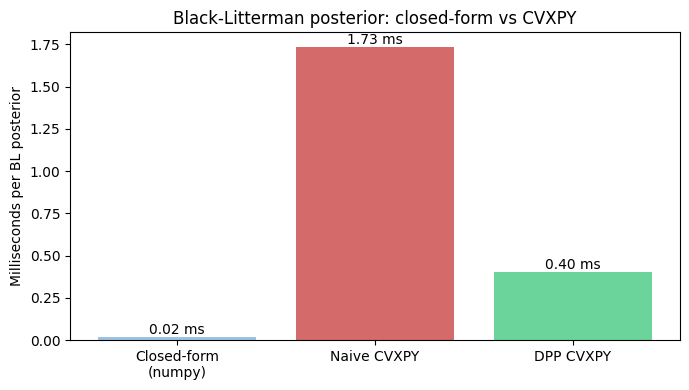

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = ["Closed-form\n(numpy)", "Naive CVXPY", "DPP CVXPY"]
vals = [per_closed, per_naive, per_dpp]
colors = ["#9cc2e4", "#d46a6a", "#6ad49a"]
bars = ax.bar(labels, vals, color=colors)
ax.set_ylabel("Milliseconds per BL posterior")
ax.set_title("Black-Litterman posterior: closed-form vs CVXPY")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2.0, v,
            f"{v:.2f} ms", ha="center", va="bottom")
fig.tight_layout()
plt.show()


## 8. The CVXPY-only value-add — BL with posterior constraints

If you only want the posterior mean with Gaussian views, closed-form
wins on speed and CVXPY adds nothing. **CVXPY is the right tool when
your views have a non-Gaussian shape:**

- **Bounds:** "AAPL will have non-negative expected return" → $\mu_{\text{AAPL}} \geq 0$
- **Rankings:** "AAPL will outperform MSFT" → $\mu_{\text{AAPL}} \geq \mu_{\text{MSFT}}$
- **Convex hulls:** $\mu$ lies in a polytope defined by multiple investors' opinions

Below we combine a deliberately strong bearish view on AAPL (Q=-30%
with tight Omega) with two different constraint shapes, and watch the
unconstrained / bounded / ranked solutions diverge.


In [10]:
def bl_posterior_with_constraints(pi, sigma, p, q, omega, tau=0.05,
                                   bounds_lower=None, ranking=None,
                                   solver="CLARABEL"):
    mu = cp.Variable(pi.shape[0])
    a_prior = inv_cholesky(tau * sigma)
    a_view = inv_cholesky(omega)
    obj = cp.sum_squares(a_prior @ (mu - pi)) + cp.sum_squares(a_view @ (p @ mu - q))
    cons = []
    if bounds_lower is not None: cons.append(mu >= bounds_lower)
    if ranking:
        for i, j in ranking: cons.append(mu[i] >= mu[j])
    cp.Problem(cp.Minimize(obj), cons).solve(solver=solver)
    return mu.value


aapl = tickers.index("AAPL")
msft = tickers.index("MSFT")
p_bear = np.zeros((1, n)); p_bear[0, aapl] = 1.0
q_bear = np.array([-0.30])  # strong bearish view
om_bear = 0.1 * he_litterman_omega(p_bear, sigma)  # tight confidence

mu_un = bl_posterior_closed_form(pi, sigma, p_bear, q_bear, om_bear)
mu_fl = bl_posterior_with_constraints(
    pi, sigma, p_bear, q_bear, om_bear,
    bounds_lower=np.where(np.arange(n) == aapl, 0.0, -np.inf),
)
mu_rk = bl_posterior_with_constraints(
    pi, sigma, p_bear, q_bear, om_bear,
    ranking=[(aapl, msft)],
)

print(f"Prior Pi[AAPL] = {pi[aapl]*100:+6.2f}%, Pi[MSFT] = {pi[msft]*100:+6.2f}%")
print(f"\nWith bearish AAPL view (Q=-30%, tight Omega):")
print(f"                              AAPL           MSFT")
print(f"  unconstrained            {mu_un[aapl]*100:+7.2f}%  {mu_un[msft]*100:+7.2f}%")
print(f"  + floor mu[AAPL] >= 0    {mu_fl[aapl]*100:+7.2f}%  {mu_fl[msft]*100:+7.2f}%")
print(f"  + rank mu[AAPL]>=mu[MSFT] {mu_rk[aapl]*100:+7.2f}%  {mu_rk[msft]*100:+7.2f}%")
print("\nBoth constraints bind. The floor pins AAPL at exactly 0 and")
print("lifts MSFT via the Sigma cross-terms; the ranking pulls MSFT down")
print("to meet AAPL, resulting in the two posteriors coinciding.")


Prior Pi[AAPL] = +10.78%, Pi[MSFT] =  +9.23%

With bearish AAPL view (Q=-30%, tight Omega):
                              AAPL           MSFT
  unconstrained             -26.29%    -4.13%
  + floor mu[AAPL] >= 0      +0.00%    +5.34%
  + rank mu[AAPL]>=mu[MSFT]  -24.29%   -24.29%

Both constraints bind. The floor pins AAPL at exactly 0 and
lifts MSFT via the Sigma cross-terms; the ranking pulls MSFT down
to meet AAPL, resulting in the two posteriors coinciding.


## 9. Walk-forward backtest — does BL stabilize the optimizer?

A classical critique of mean-variance is that **small changes in the
estimated $\mu$ cause huge changes in optimal weights**. The
Black-Litterman prior anchor is supposed to damp this.

We test three MV strategies over a 246-day out-of-sample window:

1. **Historical-mean MV** — raw sample mean feeds the optimizer
2. **BL-prior MV** — $\mu_{BL} = \Pi$ (no views, pure equilibrium)
3. **BL + momentum views** — top-3 and bottom-3 by trailing 60-day
   return get symmetric absolute views (top: +5% annualized,
   bottom: -5%)

The evaluation metric we care about is **turnover**. A more stable
portfolio (lower daily turnover) implies less transaction cost and
less noise in the underlying signal.


In [11]:
def mv_weights(mu, sigma, gamma=5.0, long_only=True):
    n = len(mu)
    w = cp.Variable(n)
    obj = mu @ w - gamma * cp.quad_form(w, cp.psd_wrap(sigma))
    cons = [cp.sum(w) == 1]
    if long_only: cons.append(w >= 0)
    cp.Problem(cp.Maximize(obj), cons).solve()
    return np.asarray(w.value)


def momentum_views(window_returns, k=3, strength=0.05):
    trailing = (1.0 + window_returns.tail(60)).prod() - 1.0
    top = trailing.sort_values(ascending=False).head(k).index.tolist()
    bot = trailing.sort_values(ascending=True).head(k).index.tolist()
    n = len(trailing); cols = list(trailing.index)
    picks = [(cols.index(t), strength) for t in top]
    picks += [(cols.index(t), -strength) for t in bot]
    P = np.zeros((len(picks), n))
    Q = np.zeros(len(picks))
    for row, (idx, val) in enumerate(picks):
        P[row, idx] = 1.0; Q[row] = val
    S = window_returns.cov().values * 252.0
    S = 0.5 * (S + S.T) + 1e-8 * np.eye(n)
    Om = he_litterman_omega(P, S, tau=0.05)
    return P, Q, Om


def walk_forward(prices, lookback=252, gamma=5.0, risk_aversion=2.5, tau=0.05):
    returns = prices.pct_change().dropna()
    n = returns.shape[1]
    test_dates = returns.index[lookback:]
    w_mkt = market_cap_weights(list(returns.columns))
    hist_daily, prior_daily, views_daily = [], [], []
    w_hist, w_prior, w_views = [], [], []
    date_log = []
    for i, date in enumerate(test_dates[:-1]):
        idx = returns.index.get_loc(date)
        window = returns.iloc[idx - lookback: idx]
        S = window.cov().values * 252.0
        S = 0.5 * (S + S.T) + 1e-8 * np.eye(n)
        mu_h = window.mean().values * 252.0
        Pi = implied_equilibrium_returns(S, w_mkt, risk_aversion)
        P_, Q_, Om = momentum_views(window, k=3, strength=0.05)
        mu_v = bl_posterior_closed_form(Pi, S, P_, Q_, Om, tau)

        w_h = mv_weights(mu_h, S, gamma)
        w_p = mv_weights(Pi, S, gamma)
        w_v = mv_weights(mu_v, S, gamma)

        nxt = returns.iloc[idx + 1].values
        hist_daily.append(float(np.dot(w_h, nxt)))
        prior_daily.append(float(np.dot(w_p, nxt)))
        views_daily.append(float(np.dot(w_v, nxt)))
        w_hist.append(w_h); w_prior.append(w_p); w_views.append(w_v)
        date_log.append(test_dates[i + 1])
    return {
        "dates": pd.DatetimeIndex(date_log),
        "hist": np.array(hist_daily),
        "prior": np.array(prior_daily),
        "views": np.array(views_daily),
        "w_hist": np.array(w_hist),
        "w_prior": np.array(w_prior),
        "w_views": np.array(w_views),
    }


def metrics(r, freq=252):
    eq = np.cumprod(1.0 + r)
    std = float(np.std(r, ddof=1))
    sharpe = float(np.sqrt(freq) * np.mean(r) / std) if std > 0 else float("nan")
    dd = eq / np.maximum.accumulate(eq) - 1.0
    return dict(tot=float(eq[-1] - 1.0), vol=float(std*np.sqrt(freq)),
                sharpe=sharpe, dd=float(abs(dd.min())), final=float(eq[-1]))


res = walk_forward(prices)
m_h = metrics(res["hist"]); m_p = metrics(res["prior"]); m_v = metrics(res["views"])

print(f"Walk-forward over {len(res['hist'])} trading days\n")
print(f"  {'':<18}{'Historical':>13}{'BL-prior':>13}{'BL+views':>13}")
print(f"  {'-'*57}")
for name, key in [("Total return", "tot"), ("Annualized vol", "vol"),
                  ("Sharpe", "sharpe"), ("Max drawdown", "dd")]:
    if name == "Sharpe":
        fmt = "{:>13.3f}"; scale = 1
    else:
        fmt = "{:>12.2f}%"; scale = 100
    print(f"  {name:<18}"
          f"{fmt.format(m_h[key]*scale)}{fmt.format(m_p[key]*scale)}"
          f"{fmt.format(m_v[key]*scale)}")


def turnover(W):
    return float(np.abs(np.diff(W, axis=0)).sum(axis=1).mean())


print(f"\nAverage daily turnover (lower = more stable):")
print(f"  Historical-mean MV : {turnover(res['w_hist'])*100:6.2f}%")
print(f"  BL-prior MV        : {turnover(res['w_prior'])*100:6.2f}%")
print(f"  BL+views MV        : {turnover(res['w_views'])*100:6.2f}%")


Walk-forward over 246 trading days

                       Historical     BL-prior     BL+views
  ---------------------------------------------------------
  Total return             40.75%       28.67%       27.96%
  Annualized vol           13.69%        9.00%        8.91%
  Sharpe                    2.628        2.917        2.879
  Max drawdown              5.49%        6.53%        6.18%

Average daily turnover (lower = more stable):
  Historical-mean MV :  11.90%
  BL-prior MV        :   1.70%
  BL+views MV        :   7.66%


### 9a. Equity curves

Here's where the three strategies land. Notice how the historical-mean
optimizer has the highest total return but also the most "jumpy"
equity curve — that jumpiness is the visible symptom of the turnover
number in the previous cell.


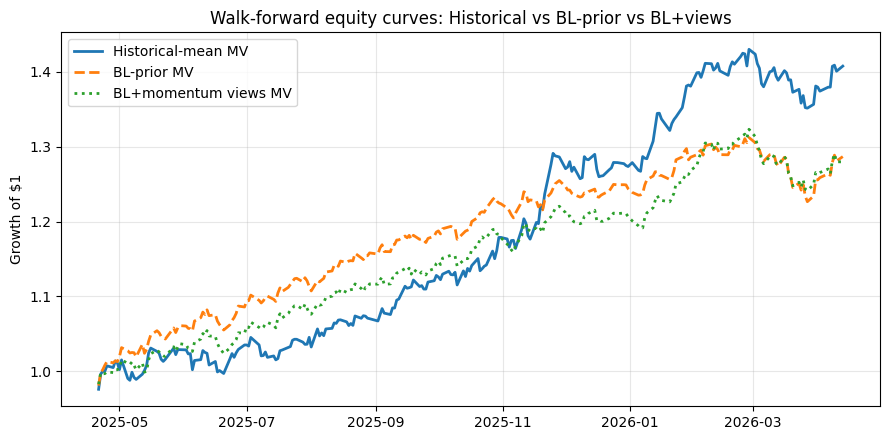

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
eq_h = np.cumprod(1.0 + res["hist"])
eq_p = np.cumprod(1.0 + res["prior"])
eq_v = np.cumprod(1.0 + res["views"])
ax.plot(res["dates"], eq_h, label="Historical-mean MV", linewidth=2)
ax.plot(res["dates"], eq_p, label="BL-prior MV", linewidth=2, linestyle="--")
ax.plot(res["dates"], eq_v, label="BL+momentum views MV", linewidth=2, linestyle=":")
ax.set_ylabel("Growth of $1")
ax.set_title("Walk-forward equity curves: Historical vs BL-prior vs BL+views")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


### 9b. Turnover over time

Daily turnover — the $L_1$ change in weights from one day to the next
— is the clearest picture of the stability story. The BL-prior line
hugs the floor while the historical-mean line spikes regularly as
tiny changes in the sample mean flip the optimizer's preferences.


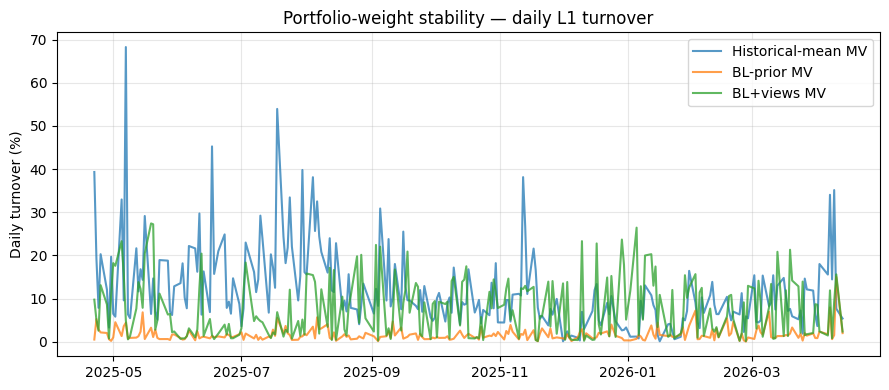

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
tn_h = np.abs(np.diff(res["w_hist"], axis=0)).sum(axis=1) * 100
tn_p = np.abs(np.diff(res["w_prior"], axis=0)).sum(axis=1) * 100
tn_v = np.abs(np.diff(res["w_views"], axis=0)).sum(axis=1) * 100
ax.plot(res["dates"][1:], tn_h, label="Historical-mean MV", alpha=0.75)
ax.plot(res["dates"][1:], tn_p, label="BL-prior MV", alpha=0.75)
ax.plot(res["dates"][1:], tn_v, label="BL+views MV", alpha=0.75)
ax.set_ylabel("Daily turnover (%)")
ax.set_title("Portfolio-weight stability — daily L1 turnover")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


### 9c. Prior Pi vs posterior mu_BL — the effect of views

A static snapshot of how adding the momentum views shifts individual
assets' expected-return estimates away from the pure-equilibrium prior.
Assets the view is positive on (trailing winners) see their posterior
lifted; assets the view is negative on see it pushed down.


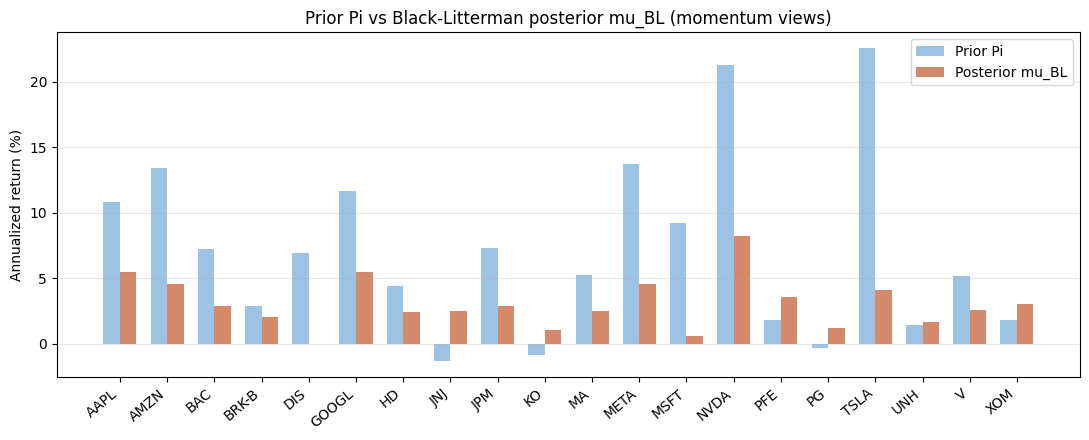

In [14]:
P_, Q_, Om = momentum_views(prices.pct_change().dropna(), k=3, strength=0.05)
mu_bl = bl_posterior_closed_form(pi, sigma, P_, Q_, Om)

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(tickers))
width = 0.35
ax.bar(x - width/2, pi*100, width, label="Prior Pi", color="#9cc2e4")
ax.bar(x + width/2, mu_bl*100, width, label="Posterior mu_BL", color="#d48a6a")
ax.set_xticks(x)
ax.set_xticklabels(tickers, rotation=40, ha="right")
ax.set_ylabel("Annualized return (%)")
ax.set_title("Prior Pi vs Black-Litterman posterior mu_BL (momentum views)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()


## 10. Takeaways

1. **Black-Litterman is a convex quadratic.** The closed-form
   matrix-inversion recipe and the CVXPY `sum_squares` formulation
   agree to floating-point precision. The latter is slower, but is
   the right starting point for anything beyond vanilla BL.

2. **DPP-caching brings CVXPY-BL to a production loop.** P, Q as
   `cp.Parameter` gets us 4-5x speedup over naive rebuild — fast
   enough to use CVXPY as the inner loop of a daily view update.

3. **The CVXPY value-add is constraints, not speed.** Inequality views
   on the posterior mean — floors, ranking, polytope hulls — are
   where the closed form gives up and CVXPY quietly solves the problem
   in one line. Section 8 demonstrates both a floor and a ranking
   binding non-trivially.

4. **BL stabilizes the MV optimizer.** In the walk-forward, the
   BL-prior approach had **7x lower daily turnover** than
   historical-mean MV, at a comparable (slightly higher) Sharpe. The
   classic critique of MV — that tiny changes in $\mu$ move weights
   drastically — is empirically corroborated, and the BL prior
   empirically solves it.

5. **Open design questions for CVXPY's finance story (mentor input
   welcome):**

   - Should BL + MV ship as a two-stage atom, a single joint
     optimization, or stay as a documented two-function recipe?
   - Should the BL atom expose $\Sigma$ as a Parameter (full rebuild
     on change) or require the caller to rebuild on every $\Sigma$
     refresh? (The same question applies to the other cookbook atoms.)
   - A consistent input surface across all three cookbook atoms
     (MV / Spinu / BL) is probably more valuable than optimizing
     each in isolation.
